# Laser Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

# Set Instruments Code

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {params.device_line_1['v_attenuator_vals']['att_blue_v']}')
# yoko.current(0)
# Check shielding: box and fridge entry 

# Import

In [1]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD11.db")
import snspd
params = snspd.snspd('snspd11.yaml')

# Set up experiment
exp_name = 'SNSPD11_11_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Logging hadn't been started.
Activating auto-logging. Current session state plus future input saved.
Filename       : C:\Users\QNL\.qcodes\logs\command_history.log
Mode           : append
Output logging : True
Raw input log  : False
Timestamping   : True
State          : active
Qcodes Logfile : C:\Users\QNL\.qcodes\logs\260520-27256-qcodes.log
Experiment loaded. Last ID no: 270


In [14]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd11.yaml')

# Instruments

In [4]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
pm100d = station.load_instrument("pm100d", revive_instance=True) 
pms120 = station.load_instrument("pms120", revive_instance=True)
tc = station.load_instrument("fridge", revive_instance=True)
p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

Connected to: Thorlabs PM100D (serial:P0033329, firmware:2.8.1) in 5.52s


2026-05-20 12:02:11,931 ¦ qcodes.instrument.instrument_base ¦ WARNING ¦ instrument_base ¦ snapshot_base ¦ 464 ¦ [pm100d(Thorlabs_PM100D)] Snapshot: Could not update parameter: beam_diameter
2026-05-20 12:02:12,083 ¦ py.warnings ¦ WARNING ¦ warnings ¦ _showwarnmsg ¦ 110 ¦ C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py:702: UserWarning: read string doesn't end with termination characters
  return self.read()



Connected to: Keithley instruments 2230G-30-1 (serial:9010428, firmware:1.16-1.04) in 0.14s


In [25]:
params.initialize_station()

Noise trace on line 1 when in reverse configuration 

In [8]:
params.capture_trace(MS, dmm, yoko, p_att)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 271. 
271
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;320.00E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #271, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

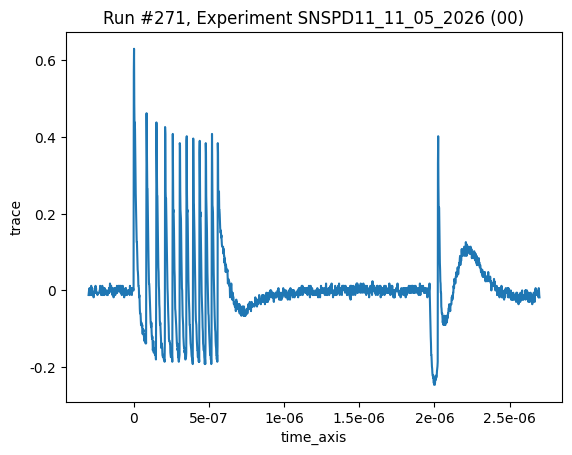

In [9]:
plot_by_id(271) # on zero current! 

Doesn't appear to be as much undershoot for this device as the device on line 2 - thresholds probably cleared it. 
For high counts with laser on do we see the right number of counts? 

In [18]:
params.MSO5_set_standard_counts(device=params.device_line_1, MS=MS)
params.ramp_yoko_current(yoko, -14e-6, 0.5e-6)
yoko.current()
yoko.current(-14e-6)

Ramping to -1.4e-05


In [20]:
threshold1, threshold2, _ = params.set_thresholds(MS, yoko, thresholds=params.device_line_1['thresholds']) # set thresholds as they would have been for counting 
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
time.sleep(5)
float(MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))

0.12

In [22]:
float(MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))

0.342

In [21]:
float(MS.ask(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold?'))

0.12

In [ ]:
# trace capture to check thresholds 

In [26]:
params.capture_trace(MS, dmm, yoko, p_att)
time.sleep(5)
params.MSO5_set_standard_counts(device=params.device_line_1, MS=MS)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 273. 
273
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;1.3950E-9;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


([<Axes: title={'center': 'Run #273, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

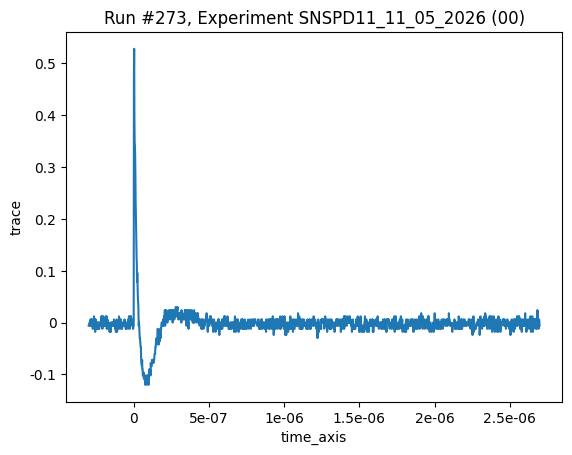

In [28]:
plot_by_id(273) # can see that thresholds are well clear of undershoot 

Laser on 

In [29]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

Laser enable status: True


Measuring ~22k in 100ms. Count is correct. 

In [30]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

Laser enable status: False


Vertical scaling may have been incorrect for lower counts - counts at 3uA may have disappeared. 

# Check Counts: Low Currents

In [31]:
params.MSO5_set_standard_counts(device=params.device_line_1, MS=MS)
params.ramp_yoko_current(yoko, -3e-6, 0.5e-6)
yoko.current()
yoko.current(-3e-6)

threshold1, threshold2, _ = params.set_thresholds(MS, yoko, thresholds=params.device_line_1['thresholds']) # set thresholds as they would have been for counting 
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
time.sleep(5)
float(MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))

Ramping to -3e-06


0.078

In [32]:
float(MS.ask(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold?'))

0.048

Counts are visible on screen at these thresholds and are not counting. Vertical scaling is currently set to 150mV. 

In [34]:
MS.channels[0].vertical_scale(100e-3)

Counts are registering when vertical scale is 100mV

In [35]:
MS.channels[0].vertical_scale(150e-3)

In [37]:
params.capture_trace(MS, dmm, yoko, p_att) # got noise because counts are sparse here 

Oscilloscope set for trace capture
update station
Starting experimental run with id: 274. 
274
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 38.4V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";6.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [39]:
MS.channels[0].vertical_scale()

0.15

([<Axes: title={'center': 'Run #274, Experiment SNSPD11_11_05_2026 (00)'}, xlabel='time_axis', ylabel='trace'>],
 [None])

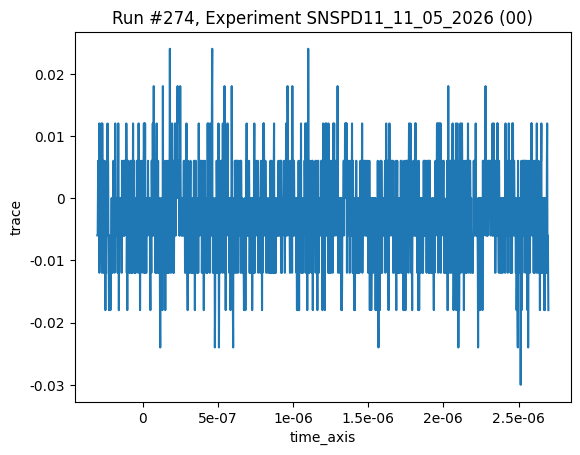

In [41]:
plot_by_id(274)

# Reset Thresholds with Vertical Scale 

In [43]:
params.MSO5_set_standard_counts(device=params.device_line_1, MS=MS)
params.ramp_yoko_current(yoko, -3e-6, 0.5e-6)
yoko.current()
yoko.current(-3e-6)

threshold1, threshold2, _ = params.set_thresholds(MS, yoko, thresholds=params.device_line_1['thresholds']) # set thresholds as they would have been for counting 
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
time.sleep(5)
print(f'T1: {float(MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))}')
print(f'T2: {float(MS.ask(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold?'))}')


Ramping to -3e-06
T1: 0.078
T2: 0.048


# Counts vs Attenuation 

In [ ]:
############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

params.laser_set_standard(laser, wavelength=1550e-9, power=7)
params.laser_get_standard(laser)
params.pmeter_set_standard(pmeter=pm100d, wavelength=1550e-9)
params.pmeter_set_standard(pmeter=pms120, wavelength=1550e-9)
params.MSO5_set_standard_counts(MS)
p_att.write(f'VOLT {v_att_range[-1]}')
yoko.current(bias)
# Check shielding: box and fridge entry 

In [ ]:
params.MSO5_set_standard_counts(device=params.device_line_1, MS=MS)
params.ramp_yoko_current(yoko, -3e-6, 0.5e-6)
yoko.current()
yoko.current(-3e-6)

threshold1, threshold2, _ = params.set_thresholds(MS, yoko, thresholds=params.device_line_1['thresholds']) # set thresholds as they would have been for counting 
MS.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
MS.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
time.sleep(5)
float(MS.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))

MS.channels[0].vertical_scale()

Counts sometimes register at 150mV

Set standard counts as above. Then stepped down current by 1uA from -13uA (down in magnitude) - counts read 0 at 

In [ ]:
threshold1, threshold2, _ = params.v

# OLD 